# Inner-Loop Environment Demonstration

This notebook showcases single-episode runs of the `NPlayerPoissonDemandEnv` for assorted numbers of sellers. Each seller is randomly assigned one meta-action from the repricer library, the inner loop runs for 100 periods, and the resulting price trajectories are plotted.

In [39]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from typing import List

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'analysis' else NOTEBOOK_DIR
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from env.NPlayerPoissonDemandEnv import NPlayerPoissonDemandEnv
from agents.repricer_meta_actions import MetaActionLibrary

np.random.seed(42)
plt.style.use('seaborn-v0_8')


In [40]:
def run_inner_loop_demo(n_players: int, periods: int = 100) -> dict:
    '''Run a single inner-loop episode for n_players with random meta actions.'''
    env = NPlayerPoissonDemandEnv(n_players=n_players)
    library = MetaActionLibrary()
    actions = [np.random.choice(library.list_actions()) for _ in range(n_players)]
    marginal_costs = np.ones(n_players) * 2
    episode = env.run_episode(
        meta_actions=actions,
        marginal_costs=marginal_costs,
        periods=periods,
        return_histories=True,
    )
    return {
        'actions': actions,
        'price_history': episode['price_history'],
        'average_profits': episode['average_profits'],
    }

def run_inner_loop_demo_limit_action(n_players: int, periods: int = 100, action_list: List[int] = [0, 1, 5, 9]) -> dict:
    '''Run a single inner-loop episode for n_players with random meta actions.'''
    env = NPlayerPoissonDemandEnv(n_players=n_players)
    library = MetaActionLibrary()
    # actions = [np.random.choice(library.list_actions()) for _ in range(n_players)]
    actions = [library.list_actions()[np.random.choice(action_list)] for _ in range(n_players)]
    marginal_costs = np.ones(n_players) * 2
    episode = env.run_episode(
        meta_actions=actions,
        marginal_costs=marginal_costs,
        periods=periods,
        return_histories=True,
    )
    return {
        'actions': actions,
        'price_history': episode['price_history'],
        'average_profits': episode['average_profits'],
    }

def run_inner_loop_fixed_action_demo(n_players: int, fixed_action_list: List, periods: int = 100) -> dict:
    '''Run a single inner-loop episode for n_players with fixed meta actions.'''
    env = NPlayerPoissonDemandEnv(n_players=n_players)
    library = MetaActionLibrary()
    actions = [library.get_action(action) for action in fixed_action_list]
    marginal_costs = np.ones(n_players) * 3
    episode = env.run_episode(
        meta_actions=actions,
        marginal_costs=marginal_costs,
        periods=periods,
        return_histories=True,
    )
    return {
        'actions': actions,
        'price_history': episode['price_history'],
        'average_profits': episode['average_profits'],
    }


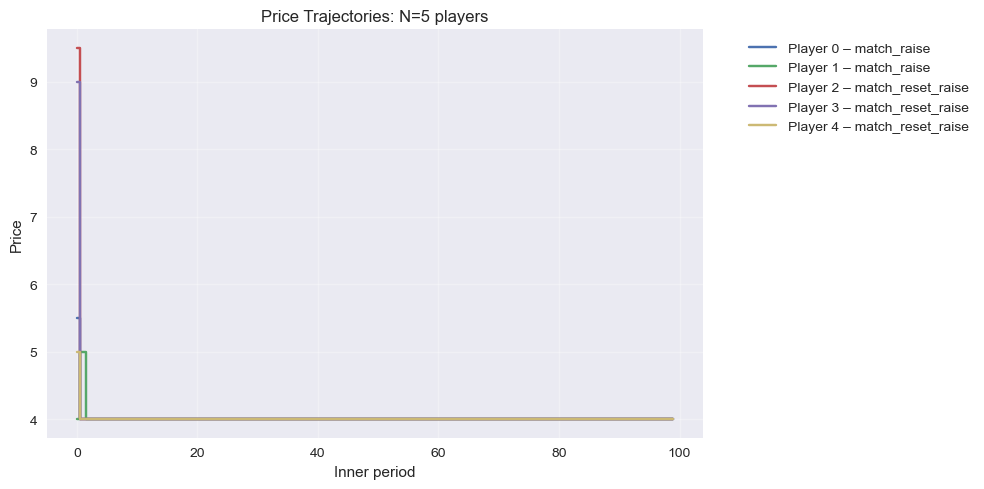

In [41]:
library = MetaActionLibrary()
scenarios = {}
for n_players in [ 5,]:
    scenarios[n_players] = run_inner_loop_fixed_action_demo(
        n_players=n_players,
        fixed_action_list=[6, 6, 8, 8, 8],
        periods=100,
    )

for n_players, data in scenarios.items():
    price_history = data['price_history']
    actions = data['actions']
    periods = price_history.shape[0]

    fig, ax = plt.subplots(figsize=(10, 5))
    for player_id, action in enumerate(actions):
        ax.step(
            range(periods),
            price_history[:, player_id],
            where='mid',
            label=f"Player {player_id} – {action.name}",
        )

    ax.set_title(f"Price Trajectories: N={n_players} players")
    ax.set_xlabel('Inner period')
    ax.set_ylabel('Price')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


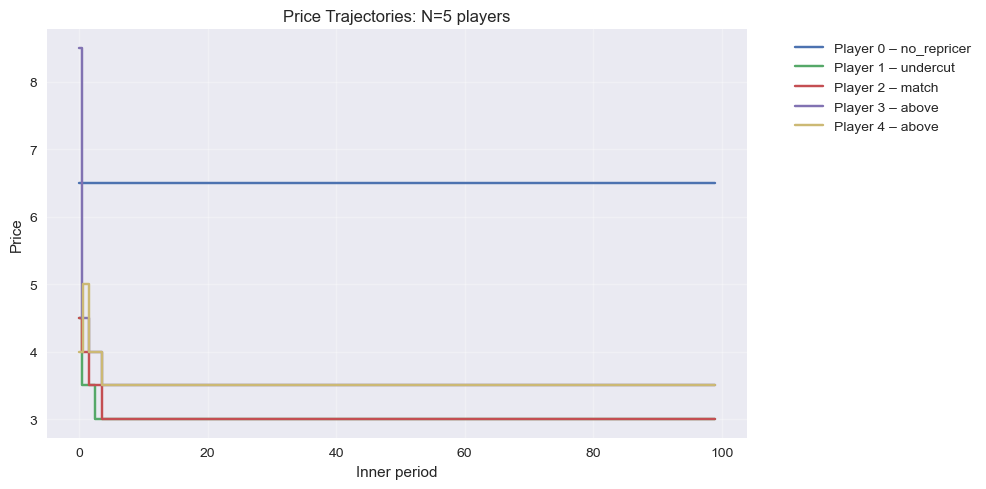

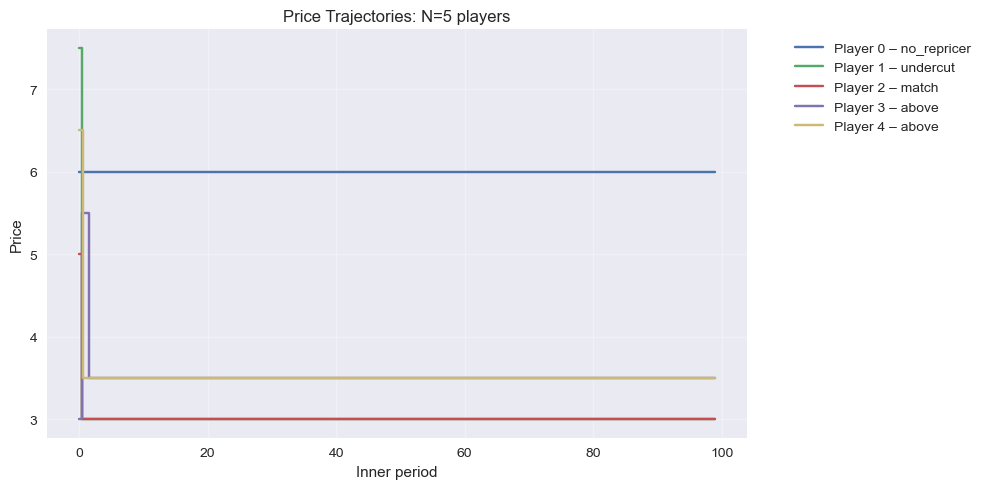

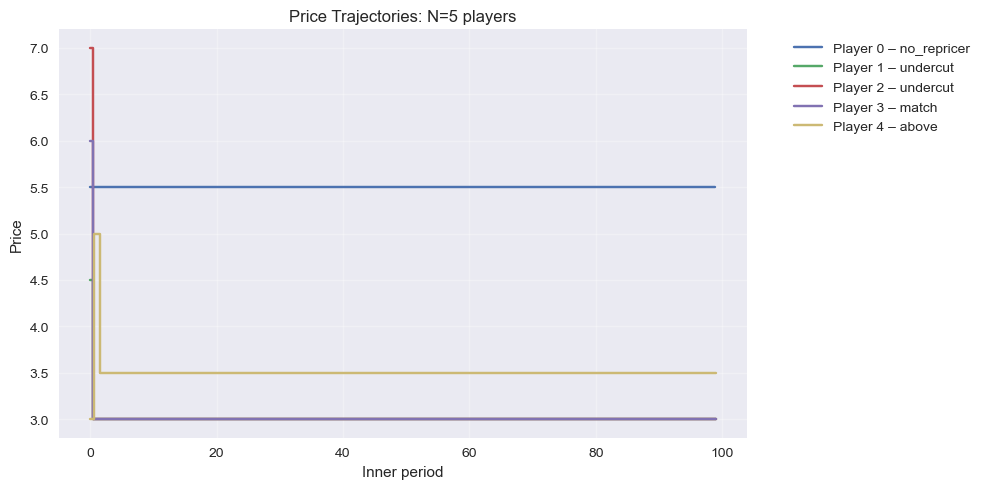

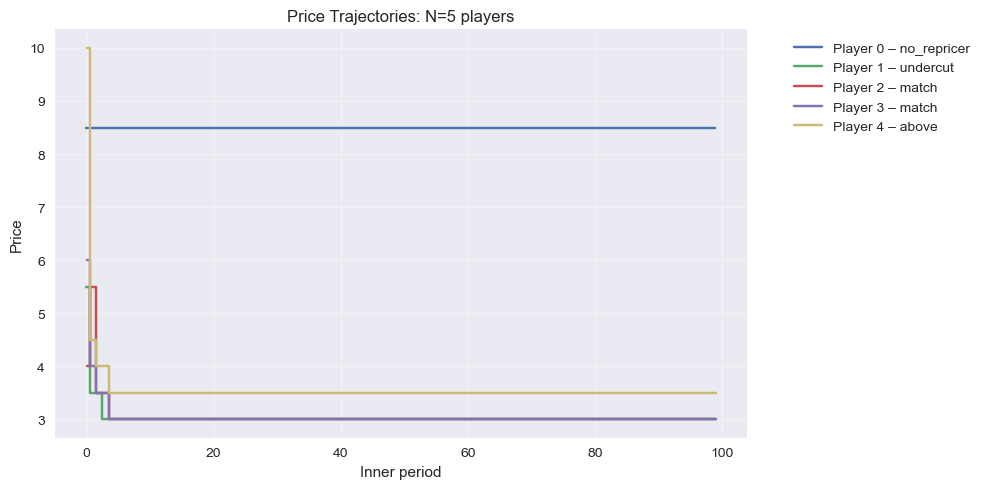

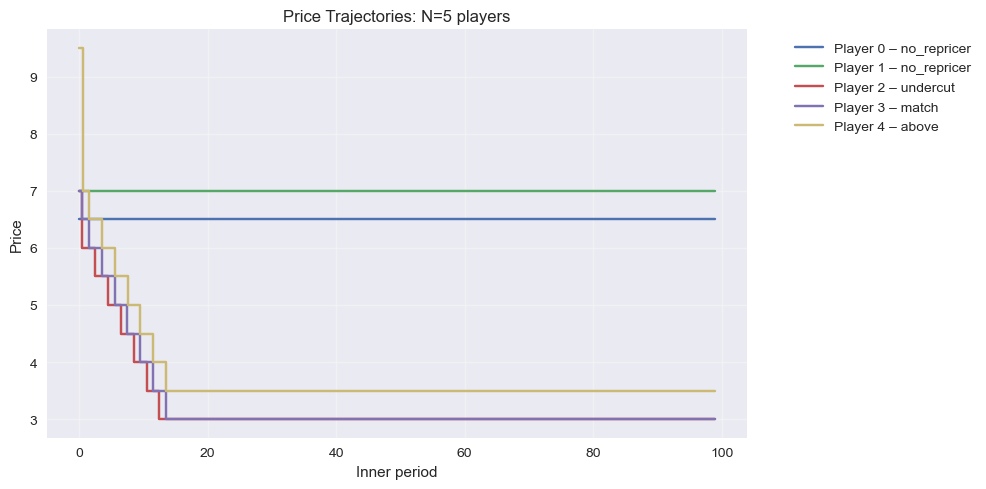

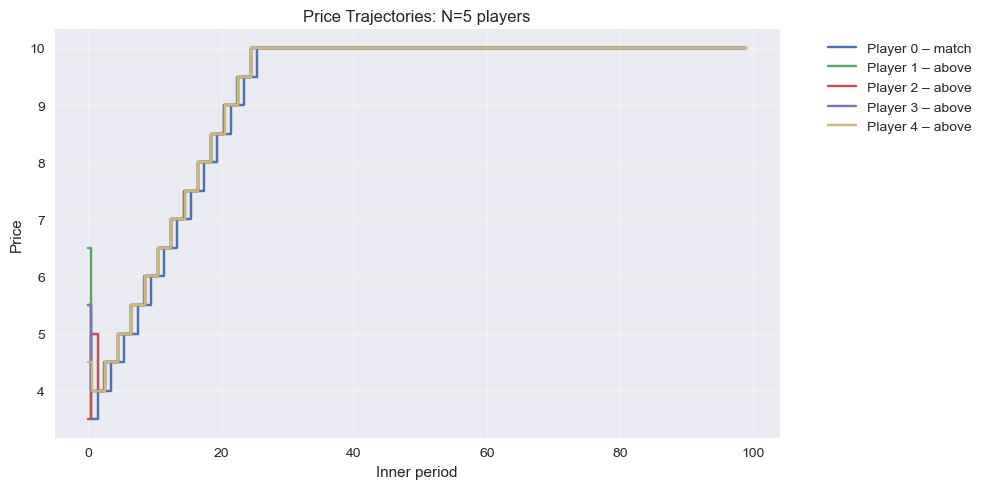

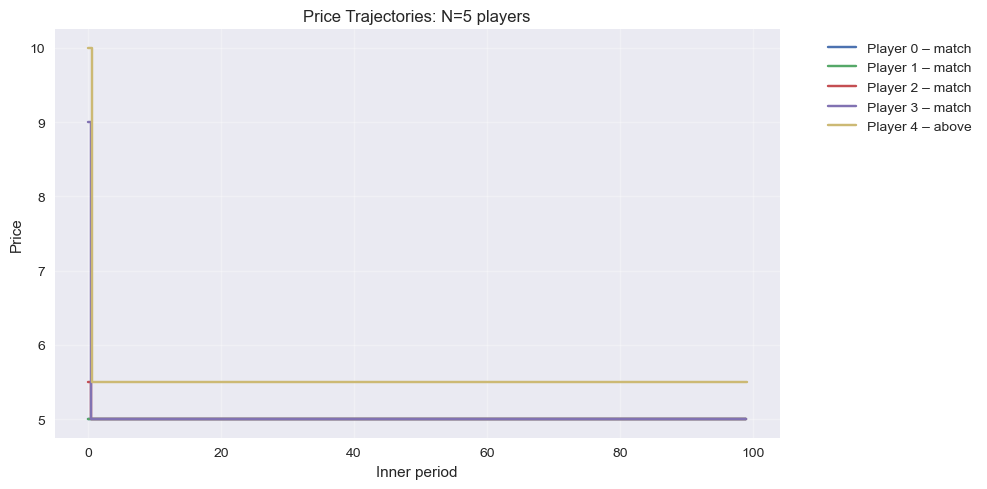

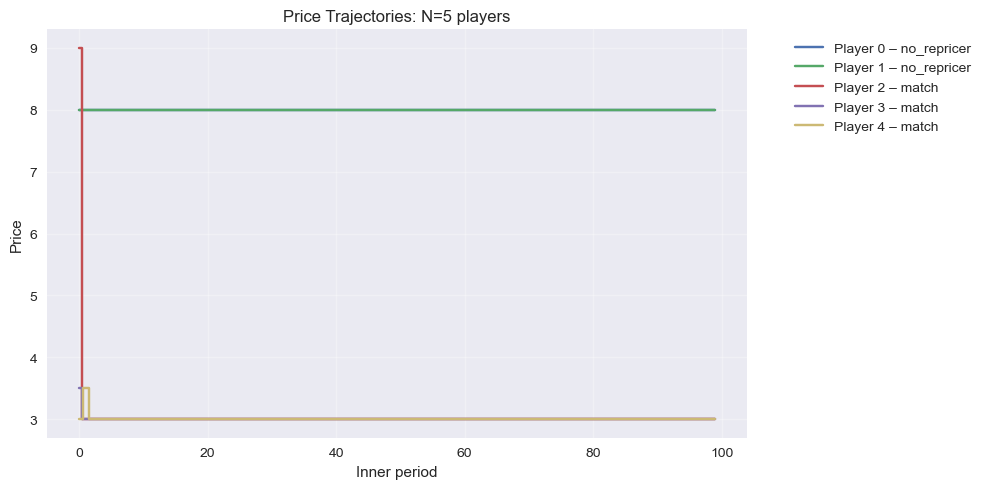

In [48]:
scenarios = []
# for i in range(10):
#     n_players = 5
#     scenarios.append(run_inner_loop_demo_limit_action(n_players, action_list=[0, 1, 5, 9],))

scenarios.append(run_inner_loop_fixed_action_demo(
    n_players=5,
    fixed_action_list=[0, 1, 5, 9, 9],
))


scenarios.append(run_inner_loop_fixed_action_demo(
    n_players=5,
    fixed_action_list=[0, 1, 5, 9, 9],
))

scenarios.append(run_inner_loop_fixed_action_demo(
    n_players=5,
    fixed_action_list=[0, 1, 1, 5, 9],
))

scenarios.append(run_inner_loop_fixed_action_demo(
    n_players=5,
    fixed_action_list=[0, 1, 5, 5, 9],
))

scenarios.append(run_inner_loop_fixed_action_demo(
    n_players=5,
    fixed_action_list=[0, 0, 1, 5, 9],
))

scenarios.append(run_inner_loop_fixed_action_demo(
    n_players=5,
    fixed_action_list=[5, 9, 9, 9, 9],
))

scenarios.append(run_inner_loop_fixed_action_demo(
    n_players=5,
    fixed_action_list=[5, 5, 5, 5, 9],
))

scenarios.append(run_inner_loop_fixed_action_demo(
    n_players=5,
    fixed_action_list=[0, 0, 5, 5, 5],
))

for data in scenarios:
    price_history = data['price_history']
    actions = data['actions']
    periods = price_history.shape[0]

    shift = 0.02
    offsets = (np.arange(len(actions)) - len(actions) / 2) * shift

    fig, ax = plt.subplots(figsize=(10, 5))
    for player_id, action in enumerate(actions):
        x = range(periods) + offsets[player_id]
        ax.step(
            x,
            price_history[:, player_id],
            where='mid',
            label=f"Player {player_id} – {action.name}",
        )

    ax.set_title(f"Price Trajectories: N={n_players} players")
    ax.set_xlabel('Inner period')
    ax.set_ylabel('Price')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


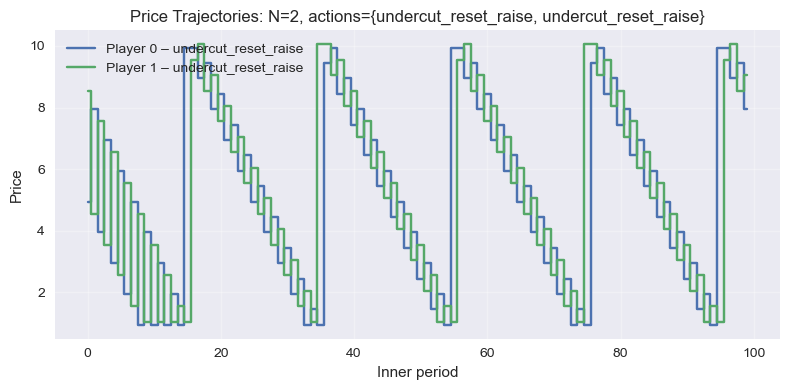

In [5]:
# Special case: N = 2, actions are {undercut_reset_raise, undercut_reset_raise}
library = MetaActionLibrary()
actions_special = [library.get_action(4)] * 2
env_special = NPlayerPoissonDemandEnv(n_players=2)
episode_special = env_special.run_episode(
    meta_actions=actions_special,
    marginal_costs=np.ones(2),
    periods=100,
    return_histories=True,
)
offsets = [-0.05, 0.05]
price_history_special = episode_special['price_history']
fig, ax = plt.subplots(figsize=(8, 4))
for player_id in range(2):
    ax.step(
        range(price_history_special.shape[0]),
        price_history_special[:, player_id] + offsets[player_id],
        where='mid',
        label=f"Player {player_id} – undercut_reset_raise",
    )
ax.set_title("Price Trajectories: N=2, actions={undercut_reset_raise, undercut_reset_raise}")
ax.set_xlabel('Inner period')
ax.set_ylabel('Price')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

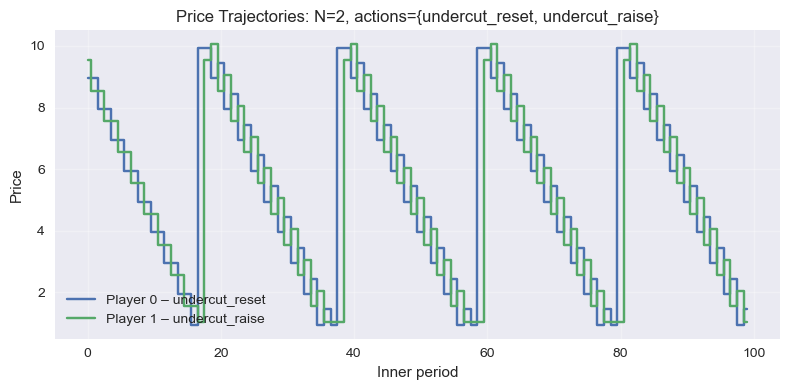

In [6]:
# Special case: N = 2, actions are {undercut_reset, undercut_raise}
library = MetaActionLibrary()
actions_special = [library.get_action(3), library.get_action(2)]
env_special = NPlayerPoissonDemandEnv(n_players=2)
episode_special = env_special.run_episode(
    meta_actions=actions_special,
    marginal_costs=np.ones(2),
    periods=100,
    return_histories=True,
)
offsets = [-0.05, 0.05]
price_history_special = episode_special['price_history']
fig, ax = plt.subplots(figsize=(8, 4))
ax.step(
        range(price_history_special.shape[0]),
        price_history_special[:, 0] + offsets[0],
        where='mid',
        label=f"Player {0} – undercut_reset",
    )
ax.step(
        range(price_history_special.shape[0]),
        price_history_special[:, 1] + offsets[1],
        where='mid',
        label=f"Player {1} – undercut_raise",
    )
ax.set_title("Price Trajectories: N=2, actions={undercut_reset, undercut_raise}")
ax.set_xlabel('Inner period')
ax.set_ylabel('Price')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()